In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import pulp as pl

#import data source
serviceRequests = pd.read_csv("311_Service_Requests_from_2020_to_Present_20251230.csv")

#drops unrelated columns
serviceRequests = serviceRequests.drop(['Agency', 'Agency Name', 'Vehicle Type', 'Taxi Company Borough', 
                                        'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 
                                        'Road Ramp', 'Bridge Highway Segment', 'Facility Type', 'Due Date', 'BBL'], axis=1)
serviceRequests = serviceRequests.drop(['Location Type', 'Street Name', 'Cross Street 1', 'Cross Street 2', 
                                        'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'Landmark', 
                                        'Resolution Description', 'Resolution Action Updated Date', 'X Coordinate (State Plane)', 
                                        'Y Coordinate (State Plane)', 'Open Data Channel Type'], axis=1)

#drops duplicate columns
serviceRequests = serviceRequests.drop_duplicates()

#formats created & closed dates
serviceRequests['Created Date'] = pd.to_datetime(serviceRequests['Created Date'], format = '%m/%d/%Y %I:%M:%S %p')
serviceRequests['created_month'] = serviceRequests['Created Date'].dt.month
serviceRequests['created_day_of_week'] = serviceRequests['Created Date'].dt.day_name()

serviceRequests['Closed Date'] = pd.to_datetime(serviceRequests['Closed Date'], format = '%m/%d/%Y %I:%M:%S %p')
serviceRequests['closed_month'] = serviceRequests['Closed Date'].dt.month
serviceRequests['closed_day_of_week'] = serviceRequests['Closed Date'].dt.day_name()

#formats city to have all caps
serviceRequests['City'] = serviceRequests['City'].str.upper()

serviceRequests

,Unique Key,Created Date,Closed Date,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Incident Zip,Incident Address,City,Status,...,Borough,Park Facility Name,Park Borough,Latitude,Longitude,Location,created_month,created_day_of_week,closed_month,closed_day_of_week
0,67256354,2025-12-22 00:17:28,NaT,Damaged Tree,Branch or Limb Has Fallen Down,Blocking Sidewalk,11426.0,246-34 85 ROAD,BELLEROSE,In Progress,...,QUEENS,Unspecified,QUEENS,40.732212,-73.720245,POINT (-73.720245310221 40.732212149294),12,Monday,NaN,NaN
1,67258391,2025-12-21 23:26:46,NaT,Damaged Tree,Branch or Limb Has Fallen Down,Blocking Street,11208.0,RUBY STREET,NaN,In Progress,...,Unspecified,Unspecified,Unspecified,40.674021,-73.861072,POINT (-73.861072237563 40.674021062491),12,Sunday,NaN,NaN
2,67256364,2025-12-21 23:11:11,NaT,Overgrown Tree/Branches,Dead Branches in Tree,NaN,11211.0,249 RUTLEDGE STREET,BROOKLYN,In Progress,...,BROOKLYN,Unspecified,BROOKLYN,40.704113,-73.953892,POINT (-73.953892271122 40.704112512386),12,Sunday,NaN,NaN
3,67260345,2025-12-21 23:04:13,NaT,Dead/Dying Tree,Planted More Than 2 Years Ago,NaN,11434.0,122-07 180 STREET,JAMAICA,In Progress,...,QUEENS,Unspecified,QUEENS,40.683960,-73.762175,POINT (-73.762175352943 40.683959940902),12,Sunday,NaN,NaN
4,67259352,2025-12-21 22:52:40,NaT,Damaged Tree,Branch Cracked and Will Fall,Hanging from Other Branches,11361.0,36-21 210 STREET,BAYSIDE,In Progress,...,QUEENS,Unspecified,QUEENS,40.766727,-73.776649,POINT (-73.776648627198 40.766727164757),12,Sunday,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486938,52940619,2022-01-01 08:47:46,2022-02-11 13:20:57,Maintenance or Facility,Structure - Outdoors,Other,10469.0,1750 BURKE AVENUE,BRONX,Closed,...,BRONX,Haffen Park,BRONX,40.874264,-73.840437,POINT (-73.840437307625 40.874264328764),1,Saturday,2.0,Friday
486939,52938368,2022-01-01 01:53:48,2025-05-13 15:36:14,New Tree Request,For One Address,Street Tree,11221.0,707 GREENE AVENUE,BROOKLYN,Closed,...,BROOKLYN,Unspecified,BROOKLYN,40.689647,-73.940409,POINT (-73.940409023594 40.689646883554),1,Saturday,5.0,Tuesday
486940,52933683,2022-01-01 01:06:49,2023-02-08 12:03:13,Root/Sewer/Sidewalk Condition,Trees and Sidewalks Program,Free Repair,11417.0,97-01 LINDEN BOULEVARD,OZONE PARK,Closed,...,QUEENS,Unspecified,QUEENS,40.674201,-73.838832,POINT (-73.838832234654 40.674200660926),1,Saturday,2.0,Wednesday
486941,52937445,2022-01-01 01:02:05,2022-01-13 12:02:05,Illegal Tree Damage,Roots Damaged,NaN,10459.0,930 FOX STREET,BRONX,Closed,...,BRONX,Unspecified,BRONX,40.820637,-73.893872,POINT (-73.89387201027 40.820636621962),1,Saturday,1.0,Thursday


In [3]:
#Fixes the nulls for City
serviceRequests.loc[(serviceRequests['City'].isna()), 'City'] = 'UNKNOWN'

#drops the columns missing longitude, latitude, and incident zip code (missing locations)
serviceRequests = serviceRequests.dropna(subset = ['Longitude', 'Latitude', 'Incident Zip'])

In [55]:
#resolution time in days (just couting days)
serviceRequests.loc[:, 'Resolution Days'] = (serviceRequests['Closed Date'] - serviceRequests['Created Date']).dt.days

#resolution time (hours)
serviceRequests.loc[:, 'Resolution Hours'] = (serviceRequests['Closed Date'] - serviceRequests['Created Date']
                                             ).dt.total_seconds() / 3600

#gets hour and day
serviceRequests.loc[:, 'hour'] = serviceRequests['Created Date'].dt.hour
serviceRequests.loc[:, 'day'] = serviceRequests['Created Date'].dt.date


In [465]:
#resolved requests
resolved_serviceRequests = serviceRequests[serviceRequests['Closed Date'].notna()]

#unresolved requests
unresolved_serviceRequests = serviceRequests[serviceRequests['Closed Date'].isna()]

In [466]:
#shows the distribution of the resolution time
resolved_serviceRequests['Resolution Hours'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    419560.000000
mean       3753.924342
std        6127.323093
min           0.002778
50%         574.409861
90%       13558.768389
95%       18571.878569
99%       25491.247456
max       34160.502500
Name: Resolution Hours, dtype: float64

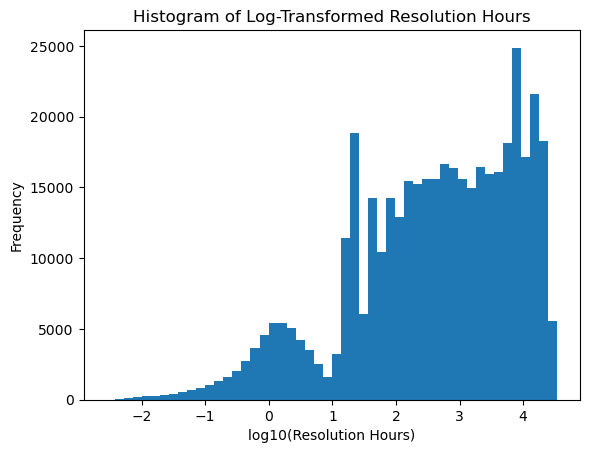

In [720]:
#histogram of resolution hours
plt.hist(np.log10(resolved_serviceRequests['Resolution Hours']), bins = 50)
plt.xlabel("log10(Resolution Hours)")
plt.ylabel("Frequency")
plt.title("Histogram of Log-Transformed Resolution Hours")
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x175e1768650>,
 'caps': [<matplotlib.lines.Line2D at 0x175e1768c50>,
 'boxes': [<matplotlib.lines.Line2D at 0x175e1717e60>],
 'medians': [<matplotlib.lines.Line2D at 0x175e1768ec0>],
 'fliers': [<matplotlib.lines.Line2D at 0x175e1769100>],
 'means': []}

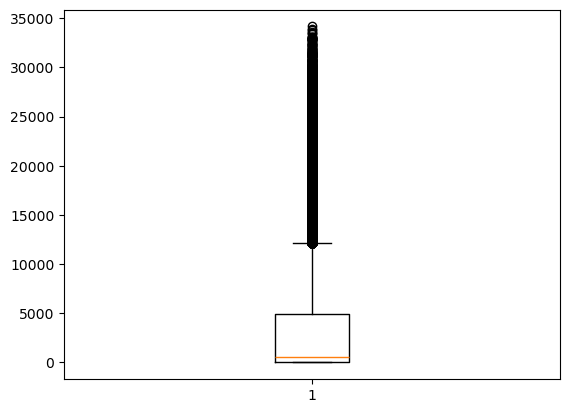

In [471]:
#box plot of resolution hours
plt.boxplot(resolved_serviceRequests['Resolution Hours'])

In [61]:
#most popular problem
serviceRequests['Problem (formerly Complaint Type)'].value_counts().head(10)

Problem (formerly Complaint Type)
Damaged Tree                     114001
Maintenance or Facility           88292
Overgrown Tree/Branches           79541
New Tree Request                  63399
Dead/Dying Tree                   40254
Root/Sewer/Sidewalk Condition     38376
Animal in a Park                  20600
Illegal Tree Damage               18749
Violation of Park Rules           16473
Wood Pile Remaining                2761
Name: count, dtype: int64

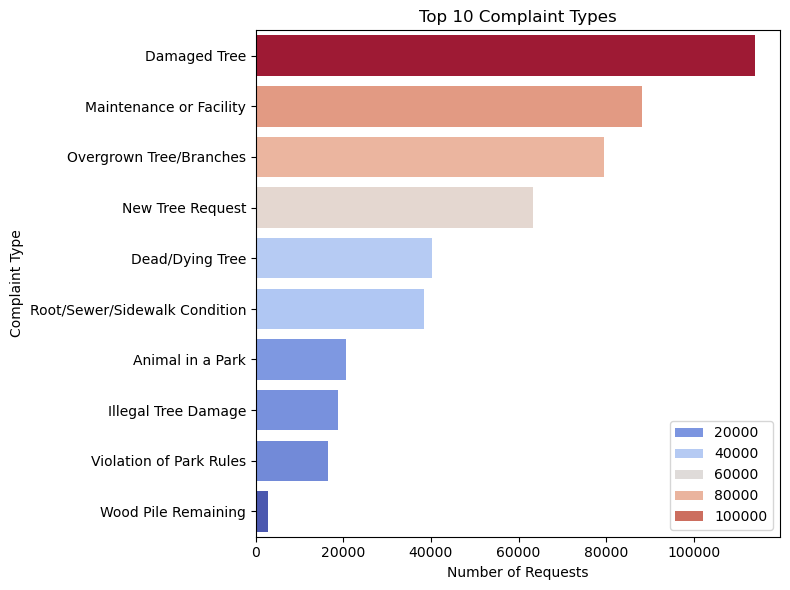

In [578]:
#Horizontal bar plot for the top 10 problems
top10 = serviceRequests['Problem (formerly Complaint Type)'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x = top10.values, y = top10.index, hue = top10.values, palette = 'coolwarm')
plt.title("Top 10 Complaint Types")
plt.xlabel("Number of Requests")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

In [113]:
#most popular unresolved problem
unresolved_serviceRequests['Problem (formerly Complaint Type)'].value_counts().head(10)

Problem (formerly Complaint Type)
Damaged Tree                     19904
Overgrown Tree/Branches          17810
Dead/Dying Tree                   9249
Root/Sewer/Sidewalk Condition     7184
Maintenance or Facility           6461
Illegal Tree Damage               2114
Uprooted Stump                     658
New Tree Request                   626
Wood Pile Remaining                435
Animal in a Park                    82
Name: count, dtype: int64

In [141]:
#most popular resolved problem
resolved_serviceRequests['Problem (formerly Complaint Type)'].value_counts().head(10)

Problem (formerly Complaint Type)
Damaged Tree                     94097
Maintenance or Facility          81831
New Tree Request                 62773
Overgrown Tree/Branches          61731
Root/Sewer/Sidewalk Condition    31192
Dead/Dying Tree                  31005
Animal in a Park                 20518
Illegal Tree Damage              16635
Violation of Park Rules          16451
Wood Pile Remaining               2326
Name: count, dtype: int64

In [63]:
#requests by borough
serviceRequests['Borough'].value_counts()

Borough
BROOKLYN         163679
QUEENS           159590
MANHATTAN         64711
STATEN ISLAND     48191
BRONX             47912
Unspecified          22
Name: count, dtype: int64

In [115]:
#unresolved requests by borough
unresolved_serviceRequests['Borough'].value_counts()

Borough
QUEENS           31834
BROOKLYN         24146
STATEN ISLAND     4436
BRONX             2692
MANHATTAN         1434
Unspecified          3
Name: count, dtype: int64

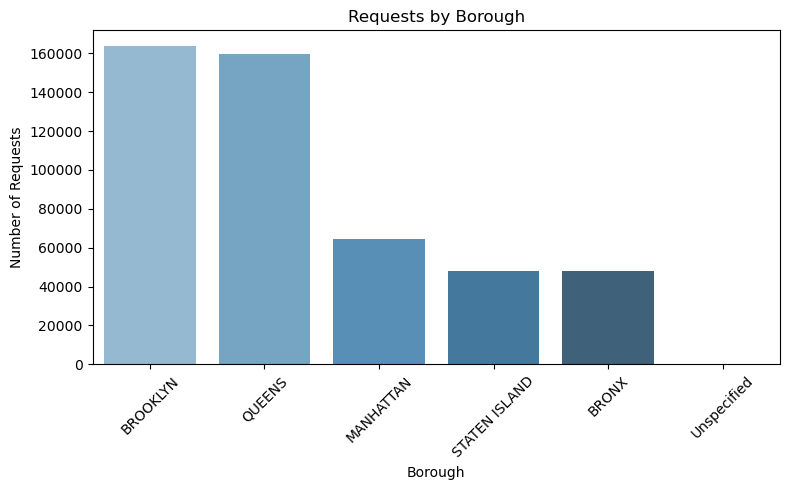

In [564]:
#bar plot for requests by borough
plt.figure(figsize = (8,5))
sns.barplot(data=serviceRequests['Borough'].value_counts().reset_index(),
            x = 'Borough', y = 'count', hue = 'Borough', palette = 'Blues_d')
plt.xlabel("Borough")
plt.ylabel("Number of Requests")
plt.title("Requests by Borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

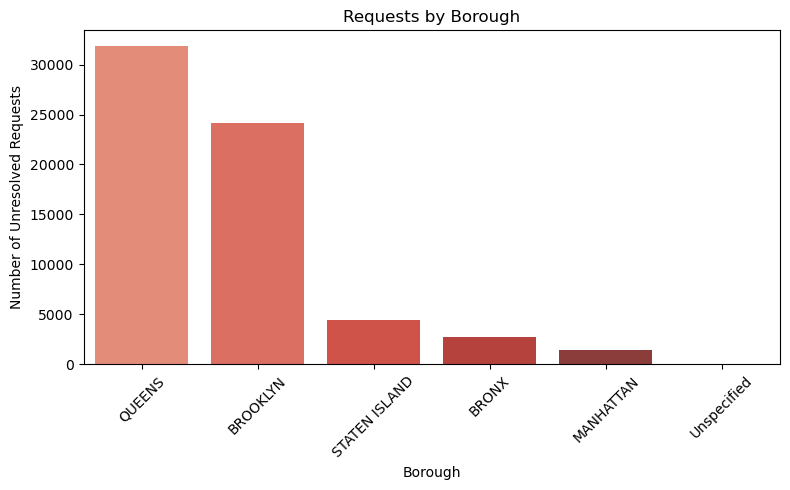

In [560]:
#bar plot for reolved requests by borough
plt.figure(figsize = (8,5))
sns.barplot(data=unresolved_serviceRequests['Borough'].value_counts().reset_index(),
            x ='Borough', y ='count', hue = 'Borough', palette = 'Reds_d')
plt.xlabel("Borough")
plt.ylabel("Number of Unresolved Requests")
plt.title("Requests by Borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [407]:
#what requests take the longest
round(resolved_serviceRequests.groupby('Problem (formerly Complaint Type)')['Resolution Hours'].median().sort_values(ascending = False), 2)

Problem (formerly Complaint Type)
New Tree Request                 8906.27
Root/Sewer/Sidewalk Condition    2743.18
Uprooted Stump                   1057.23
Overgrown Tree/Branches           815.27
Dead/Dying Tree                   628.71
Maintenance or Facility           444.12
Illegal Tree Damage               349.69
Wood Pile Remaining               337.61
Damaged Tree                      162.97
Animal in a Park                    1.29
Violation of Park Rules             0.99
Name: Resolution Hours, dtype: float64

In [411]:
#what borough takes the longest to solve requests
round(resolved_serviceRequests.groupby('Borough')['Resolution Hours'].median().sort_values(ascending = False), 2)

Borough
BROOKLYN         985.67
QUEENS           608.78
Unspecified      394.05
MANHATTAN        362.46
BRONX            238.43
STATEN ISLAND    180.73
Name: Resolution Hours, dtype: float64

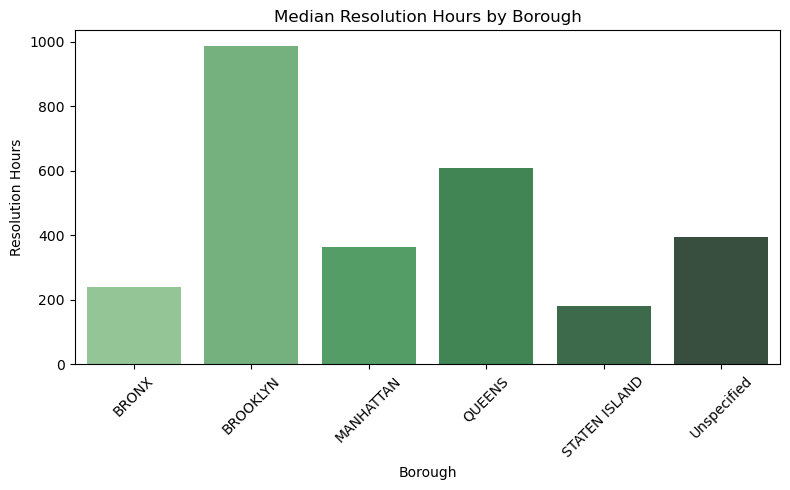

In [558]:
#median resolution time by borough
median_res = resolved_serviceRequests.groupby('Borough')['Resolution Hours'].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data = median_res, x = 'Borough', y = 'Resolution Hours', hue = 'Borough', palette = 'Greens_d')
plt.title("Median Resolution Hours by Borough")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


In [413]:
#what problem takes the longest by borough
round(resolved_serviceRequests.groupby(['Problem (formerly Complaint Type)', 'Borough'])['Resolution Hours'].median().sort_values(ascending=False), 2)

Problem (formerly Complaint Type)  Borough      
Illegal Tree Damage                Unspecified      22301.98
New Tree Request                   STATEN ISLAND    16499.38
                                   Unspecified      15280.75
                                   QUEENS           10209.08
                                   MANHATTAN         8710.42
                                                      ...   
Violation of Park Rules            QUEENS               0.96
                                   BRONX                0.93
Animal in a Park                   STATEN ISLAND        0.83
Violation of Park Rules            STATEN ISLAND        0.67
                                   Unspecified          0.29
Name: Resolution Hours, Length: 62, dtype: float64

In [101]:
#what day of week makes the most requests
serviceRequests.groupby('created_day_of_week').size()

created_day_of_week
Friday       71448
Monday       82400
Saturday     48565
Sunday       49719
Thursday     74689
Tuesday      79132
Wednesday    78152
dtype: int64

In [117]:
#what day of week resolves most requests
resolved_serviceRequests.groupby('closed_day_of_week').size()

closed_day_of_week
Friday        67525
Monday        72245
Saturday      12796
Sunday        11771
Thursday      61832
Tuesday      127989
Wednesday     65402
dtype: int64

In [97]:
#what time makes the most requests
serviceRequests.groupby('hour').size()

hour
0      3517
1      2065
2      1342
3       985
4       961
5      1800
6      5659
7     15099
8     27042
9     38307
10    42565
11    42918
12    39772
13    37919
14    37101
15    36078
16    35049
17    30600
18    23758
19    19225
20    14880
21    11784
22     9515
23     6164
dtype: int64

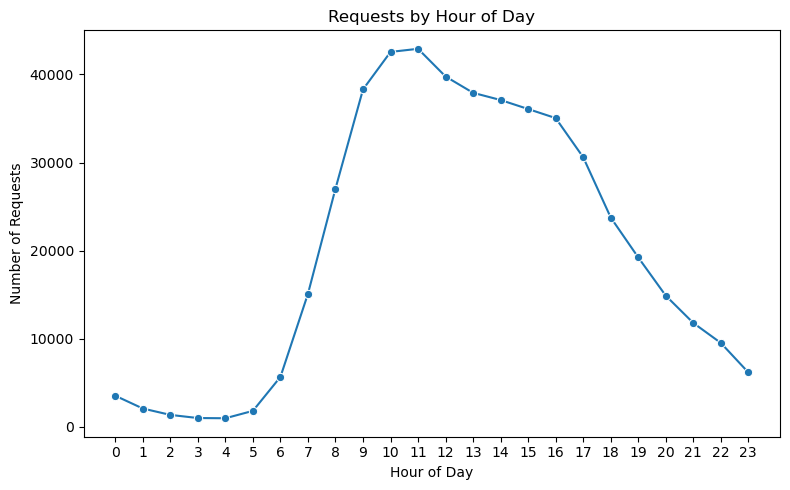

In [566]:
#line chart for requests by hour
hourly = serviceRequests.groupby('hour').size().reset_index(name = 'count')

plt.figure(figsize=(8,5))
sns.lineplot(data = hourly, x = 'hour', y = 'count', marker = 'o')
plt.title("Requests by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

In [119]:
#what time resolved the most requests
resolved_serviceRequests.groupby('hour').size()

hour
0      3106
1      1786
2      1178
3       876
4       842
5      1592
6      5029
7     13398
8     23604
9     33094
10    36526
11    36843
12    34141
13    32552
14    31910
15    31190
16    30198
17    26908
18    20719
19    16843
20    12987
21    10335
22     8450
23     5453
dtype: int64

In [121]:
#service requests by month
serviceRequests.groupby('created_month').size()

created_month
1     18929
2     17612
3     29377
4     37566
5     53170
6     64928
7     65234
8     59677
9     48940
10    42824
11    26152
12    19696
dtype: int64

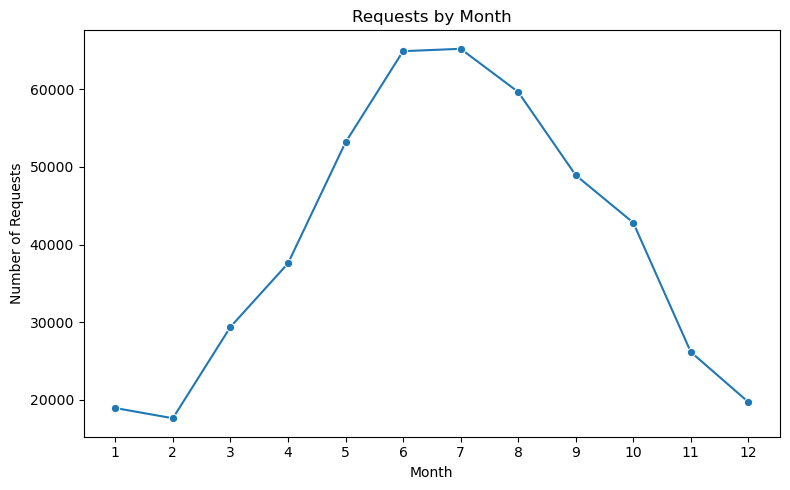

In [574]:
#line chart for requests by month
monthly = serviceRequests.groupby('created_month').size().reset_index(name = 'count')

plt.figure(figsize=(8,5))
sns.lineplot(data = monthly, x = 'created_month', y = 'count', marker = 'o')
plt.title("Requests by Month")
plt.xlabel("Month")
plt.ylabel("Number of Requests")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

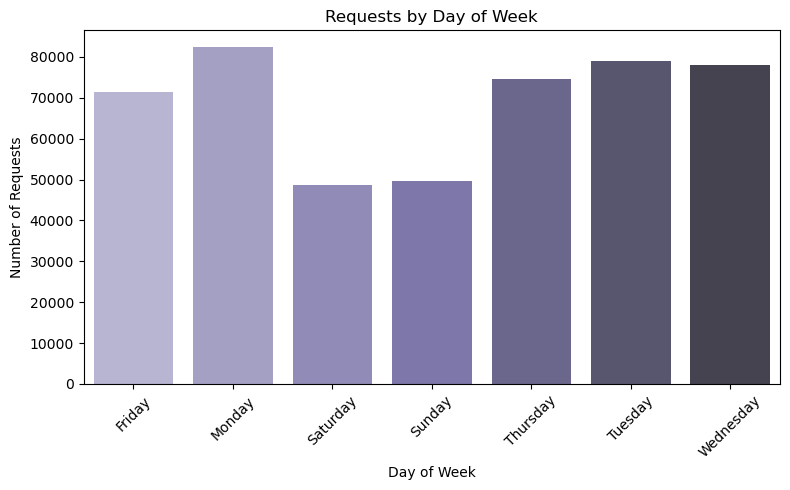

In [570]:
#barplot for requests created on each day of the week
dow = serviceRequests.groupby('created_day_of_week').size().reset_index(name = 'count')

plt.figure(figsize=(8,5))
sns.barplot(data = dow, x = 'created_day_of_week', y = 'count', hue = 'created_day_of_week', palette = 'Purples_d')
plt.title("Requests by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [123]:
#what month resolves the most cases
serviceRequests.groupby('closed_month').size()

closed_month
1.0     24644
2.0     21109
3.0     28298
4.0     26630
5.0     59278
6.0     41622
7.0     40761
8.0     37168
9.0     36489
10.0    39338
11.0    39844
12.0    24379
dtype: int64

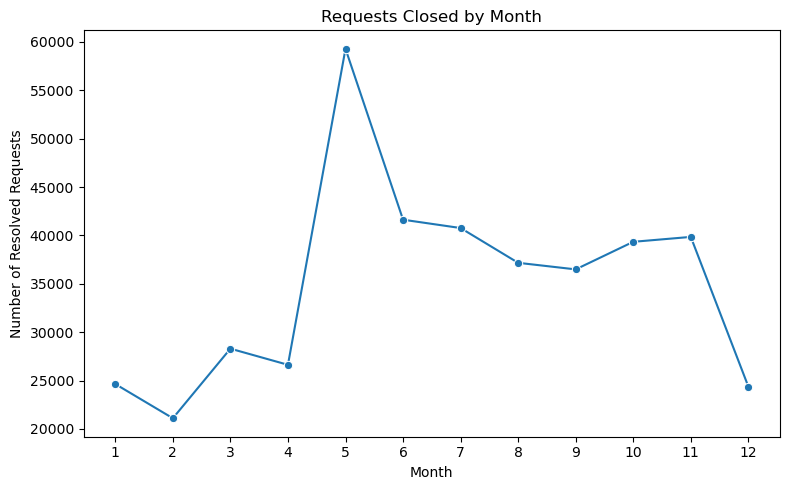

In [576]:
#line chart for requests resolved by month
monthly = serviceRequests.groupby('closed_month').size().reset_index(name = 'count')

plt.figure(figsize=(8,5))
sns.lineplot(data = monthly, x = 'closed_month', y = 'count', marker = 'o')
plt.title("Requests Closed by Month")
plt.xlabel("Month")
plt.ylabel("Number of Resolved Requests")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

In [415]:
#resolution time by requested hour
resolved_serviceRequests.groupby('hour')['Resolution Hours'].median()

hour
0     632.896111
1     589.624722
2     431.716111
3     438.454167
4     487.002917
5     580.488889
6     366.411389
7     268.750000
8     360.929028
9     507.901250
10    578.660417
11    696.235833
12    648.908611
13    668.209722
14    624.716528
15    666.316806
16    646.430833
17    620.305417
18    451.588056
19    523.557500
20    595.326944
21    661.707778
22    913.578472
23    611.735000
Name: Resolution Hours, dtype: float64

In [419]:
#resolution time by requested month
resolved_serviceRequests.groupby('created_month')['Resolution Hours'].median()

created_month
1     438.035000
2     272.855833
3     361.936111
4     477.579167
5     691.638194
6     808.308333
7     743.055833
8     672.870278
9     699.068889
10    559.174583
11    422.348333
12    189.655556
Name: Resolution Hours, dtype: float64

In [421]:
#resolution time by closed month
resolved_serviceRequests.groupby('closed_month')['Resolution Hours'].median()

closed_month
1.0     2155.901806
2.0     1539.687778
3.0      606.137917
4.0      215.447361
5.0     8593.738750
6.0      283.893194
7.0      209.093611
8.0      205.930417
9.0      380.838056
10.0     651.622500
11.0    2116.479861
12.0     861.538333
Name: Resolution Hours, dtype: float64

In [766]:
#demand by day
daily_demand = serviceRequests.groupby('day').size()
#demand by day and location
spatial_demand = serviceRequests.groupby(['day', 'Borough']).size().reset_index(name = 'demand')

#the demand for the day before
spatial_demand['lag'] = spatial_demand.groupby('Borough')['demand'].shift(1)
#difference in demand by day to day
spatial_demand['change'] = spatial_demand['demand'] - spatial_demand['lag']
#how likely it is to change quickly
spatial_demand['volatility'] = spatial_demand.groupby('Borough')['demand'].rolling(7).std().reset_index(level = 0, drop = True)

#average demand
borough_avg = spatial_demand.groupby('day')['demand'].mean()

# backlog (unresolved load)
backlog = unresolved_serviceRequests.groupby('Borough').size()

# resolution rate
resolution_rate = (resolved_serviceRequests.groupby('Borough').size() / serviceRequests.groupby('Borough').size())

#shows all data after a week which is when volatility is calculated
spatial_demand[spatial_demand['volatility'].notna()]

,day,Borough,demand,lag,change,volatility
30,2022-01-07,BRONX,11,7.0,4.0,2.449490
31,2022-01-07,BROOKLYN,40,44.0,-4.0,10.721585
32,2022-01-07,MANHATTAN,19,22.0,-3.0,4.572173
33,2022-01-07,QUEENS,27,82.0,-55.0,21.061136
34,2022-01-07,STATEN ISLAND,12,21.0,-9.0,5.798193
...,...,...,...,...,...,...
7268,2025-12-21,MANHATTAN,14,19.0,-5.0,13.259318
7269,2025-12-21,QUEENS,67,84.0,-17.0,89.204687
7270,2025-12-21,STATEN ISLAND,10,12.0,-2.0,9.357961
7271,2025-12-21,Unspecified,1,1.0,0.0,0.377964


In [768]:
#average volatility by borough
spatial_demand.groupby('Borough')['volatility'].mean()

Borough
BRONX            11.724676
BROOKLYN         37.173874
MANHATTAN        13.414586
QUEENS           39.793169
STATEN ISLAND    14.767289
Unspecified       0.601016
Name: volatility, dtype: float64

In [770]:
#distribute workers amongst the boroughs based on demand, resolution time, and backlog

#median resolution time and demand (number of requests) by borough
priorityDemand = serviceRequests.groupby('Borough').agg({
    'Resolution Hours': 'median', 'Unique Key': 'count'}).rename(columns={'Unique Key': 'demand'})

#creates backlog to show how many unresolved cases each borough has
priorityDemand['backlog'] = unresolved_serviceRequests.groupby('Borough').size()

# total workload (you can tune the backlog weight)
priorityDemand['workload'] = priorityDemand['demand'] + 2 * priorityDemand['backlog']

# capacity per worker (cases per hour) ~ 1 / Resolution Hours
priorityDemand['capacity_per_worker'] = 1 / priorityDemand['Resolution Hours']
#average change by borough
priorityDemand['trend'] = spatial_demand.groupby('Borough')['change'].mean()
#average volatility by borough
priorityDemand['volatility'] = spatial_demand.groupby('Borough')['volatility'].mean()

#creates a score based on demand having the most effct followed by average time and the backlog
priorityDemand['score'] = (priorityDemand['demand'] * 0.5 + 
                           priorityDemand['Resolution Hours'] * 0.2 + 
                           priorityDemand['backlog'] * 0.3)

#takes in affect the volatility
priorityDemand['score'] += priorityDemand['volatility'] * 0.1

# Allocate 1000 workers proportionally
total_workers = 1000
#rounds as you can't have half a person
priorityDemand['workers_allocated'] = round(priorityDemand['score'] / priorityDemand['score'].sum() * total_workers)

priorityDemand

,Resolution Hours,demand,backlog,workload,capacity_per_worker,trend,volatility,score,workers_allocated
Borough,,,,,,,,,
BRONX,238.431944,47912,2692,53296,0.004194,0.003448,11.724676,24812.458857,95.0
BROOKLYN,985.673333,163679,24146,211971,0.001015,0.018621,37.173874,89284.152054,341.0
MANHATTAN,362.457222,64711,1434,67579,0.002759,0.001379,13.414586,32859.532903,125.0
QUEENS,608.776806,159590,31834,223258,0.001643,-0.009649,39.793169,89470.934678,342.0
STATEN ISLAND,180.733611,48191,4436,57063,0.005533,0.004831,14.767289,25463.923451,97.0
Unspecified,394.050278,22,3,28,0.002538,0.000000,0.601016,90.770157,0.0


In [975]:
#minminize difference between demand and available workers in high demand and slow resolution areas
#uses median resolution time
priority = serviceRequests.groupby('Borough').agg({
    'Resolution Hours': 'median', 'Unique Key': 'count'}).rename(columns={'Unique Key': 'demand'})

#gets how many unresolved reuqests by borough
priority['backlog'] = unresolved_serviceRequests.groupby('Borough').size()

# total workload
priority['workload'] = priority['demand'] + 2 * priority['backlog']

# capacity per worker (cases per hour) ~ 1 / Resolution Hours
priority['capacity_per_worker'] = 1 / priority['Resolution Hours']

# workload in hours
priority['workload_hours'] = priority['workload'] * priority['Resolution Hours']
total_workload = priority['workload_hours'].sum()

# Decision variables
#workers[b] = number of workers assigned to borough b
workers = pl.LpVariable.dicts('workers', boroughs, lowBound = 0, cat = 'Integer')
#over[b], under[b] = slack variables capturing deviation from ideal proportional allocation
over = pl.LpVariable.dicts('over', boroughs, lowBound = 0)
under = pl.LpVariable.dicts('under', boroughs, lowBound = 0)

#workers to be distributed
total_workers = 1000

#model
#Objective: minimize total proportional mismatch across all boroughs (sum of over + under deviations)
model = pl.LpProblem('WorkerAllocation', pl.LpMinimize)
model += pl.lpSum([over[b] + under[b] for b in boroughs])

#Proportional fairness constraints
for b in boroughs:
    #borough's share of total workload
    workload_prop = priority.loc[b, 'workload_hours'] / total_workload

    #constraint
    model += workload_prop - workers[b] / total_workers == over[b] - under[b]
    
    #minimum of workers
    model += workers[b] >= 10

#ensures 1000 workers are distributed
model += pl.lpSum([workers[b] for b in boroughs]) == total_workers

#solved the model
model.solve()

#stores the results & displays
priority['workers_optimized'] = [workers[b].varValue for b in boroughs]
priority

,Resolution Hours,demand,backlog,workload,capacity_per_worker,workload_hours,workers_optimized
Borough,,,,,,,
BRONX,238.431944,47912,2692,53296,0.004194,1.270747e+07,24.0
BROOKLYN,985.673333,163679,24146,211971,0.001015,2.089342e+08,532.0
MANHATTAN,362.457222,64711,1434,67579,0.002759,2.449450e+07,62.0
QUEENS,608.776806,159590,31834,223258,0.001643,1.359143e+08,346.0
STATEN ISLAND,180.733611,48191,4436,57063,0.005533,1.031320e+07,26.0
Unspecified,394.050278,22,3,28,0.002538,1.103341e+04,10.0


In [910]:
#forcasting demand allocation using median
priority_forecast = serviceRequests.groupby('Borough').agg({
    'Resolution Hours': 'median', 'Unique Key': 'count'}).rename(columns={'Unique Key': 'demand'})

#gets how many unresolved reuqests by borough
priority_forecast['backlog'] = unresolved_serviceRequests.groupby('Borough').size()
priority_forecast['trend'] = spatial_demand.groupby('Borough')['change'].mean()
priority_forecast['forecast_demand'] = priority_forecast['demand'] * (1 + priority_forecast['trend'].fillna(0))
# total workload
priority_forecast['workload'] = priority_forecast['forecast_demand'] + 2 * priority_forecast['backlog']

# capacity per worker (cases per hour) ~ 1 / Resolution Hours
priority_forecast['capacity_per_worker'] = 1 / priority_forecast['Resolution Hours']

# workload in hours
priority_forecast['workload_hours'] = priority_forecast['workload'] * priority_forecast['Resolution Hours']
total_workload = priority_forecast['workload_hours'].sum()

# Decision variables
#workers[b] = number of workers assigned to borough b
workers = pl.LpVariable.dicts('workers', boroughs, lowBound = 0, cat = 'Integer')
#over[b], under[b] = slack variables capturing deviation from ideal proportional allocation
over = pl.LpVariable.dicts('over', boroughs, lowBound = 0)
under = pl.LpVariable.dicts('under', boroughs, lowBound = 0)

#workers to be distributed
total_workers = 1000

#model
#Objective: minimize total proportional mismatch across all boroughs (sum of over + under deviations)
model = pl.LpProblem('WorkerAllocation', pl.LpMinimize)
model += pl.lpSum([over[b] + under[b] for b in boroughs])

#Proportional fairness constraints
for b in boroughs:
    #borough's share of total workload
    workload_prop = priority_forecast.loc[b, 'workload_hours'] / total_workload

    #constraint
    model += workload_prop - workers[b] / total_workers == over[b] - under[b]
    
    #minimum of workers
    model += workers[b] >= 10

#ensures 1000 workers are distributed
model += pl.lpSum([workers[b] for b in boroughs]) == total_workers

#solved the model
model.solve()

#stores the results & displays
priority_forecast['workers_optimized'] = [workers[b].varValue for b in boroughs]
priority_forecast

,Resolution Hours,demand,backlog,trend,forecast_demand,workload,capacity_per_worker,workload_hours,workers_optimized
Borough,,,,,,,,,
BRONX,238.431944,47912,2692,0.003448,48077.213793,53461.213793,0.004194,1.274686e+07,23.0
BROOKLYN,985.673333,163679,24146,0.018621,166726.815862,215018.815862,0.001015,2.119383e+08,537.0
MANHATTAN,362.457222,64711,1434,0.001379,64800.256552,67668.256552,0.002759,2.452685e+07,62.0
QUEENS,608.776806,159590,31834,-0.009649,158050.192970,221718.192970,0.001643,1.349769e+08,342.0
STATEN ISLAND,180.733611,48191,4436,0.004831,48423.806763,57295.806763,0.005533,1.035528e+07,26.0
Unspecified,394.050278,22,3,0.000000,22.000000,28.000000,0.002538,1.103341e+04,10.0


In [913]:
#minminize difference between demand and available workers in high demand and slow resolution areas
#mean resolution time
priority_mean = serviceRequests.groupby('Borough').agg({
    'Resolution Hours': 'mean', 'Unique Key': 'count'}).rename(columns={'Unique Key': 'demand'})

#gets how many unresolved reuqests by borough
priority_mean['backlog'] = unresolved_serviceRequests.groupby('Borough').size()

# total workload (you can tune the backlog weight)
priority_mean['workload'] = priority_mean['demand'] + 2 * priority_mean['backlog']

# capacity per worker (cases per hour) ~ 1 / Resolution Hours
priority_mean['capacity_per_worker'] = 1 / priority_mean['Resolution Hours']

# workload in hours
priority_mean['workload_hours'] = priority_mean['workload'] * priority_mean['Resolution Hours']
total_workload = priority_mean['workload_hours'].sum()

# Decision variables
#workers[b] - number of workers assigned to borough b
workers = pl.LpVariable.dicts('workers', boroughs, lowBound = 0, cat = 'Integer')
#over[b], under[b] - slack variables capturing deviation from ideal proportional allocation
over = pl.LpVariable.dicts('over', boroughs, lowBound=0)
under = pl.LpVariable.dicts('under', boroughs, lowBound=0)

#workers to be distributed
total_workers = 1000

#model
#minimize total proportional mismatch across all boroughs (sum of over + under deviations)
model = pl.LpProblem('WorkerAllocation', pl.LpMinimize)
model += pl.lpSum([2*over[b] + under[b] for b in boroughs])

#Proportional fairness constraints
for b in boroughs:
    #borough's share of total workload
    workload_prop = priority_mean.loc[b, 'workload_hours'] / total_workload

    #constraint
    model += workload_prop - workers[b] / total_workers == over[b] - under[b]
    
    #minimum of workers
    model += workers[b] >= 10

#ensures 1000 workers are distributed
model += pl.lpSum([workers[b] for b in boroughs]) == total_workers

#solved the model
model.solve()

#stores the results & displays
priority_mean['workers_optimized'] = [workers[b].varValue for b in boroughs]
priority_mean

,Resolution Hours,demand,backlog,workload,capacity_per_worker,workload_hours,workers_optimized
Borough,,,,,,,
BRONX,2656.004600,47912,2692,53296,0.000377,1.415544e+08,53.0
BROOKLYN,4204.492191,163679,24146,211971,0.000238,8.912304e+08,379.0
MANHATTAN,3212.092327,64711,1434,67579,0.000311,2.170700e+08,92.0
QUEENS,4043.999526,159590,31834,223258,0.000247,9.028552e+08,384.0
STATEN ISLAND,3387.335779,48191,4436,57063,0.000295,1.932915e+08,82.0
Unspecified,6153.333202,22,3,28,0.000163,1.722933e+05,10.0


In [915]:
#compares the different results from the four models
combined_side = pd.concat(
    [priority_mean['workers_optimized'], priority['workers_optimized'], priority_forecast['workers_optimized'], priorityDemand['workers_allocated']],
    axis=1,
    keys=['Mean Resolution', 'Median Resolution', 'Forecast', 'Heuristic']  # Creates a multi-level column header
)
combined_side

,Mean Resolution,Median Resolution,Forecast,Heuristic
Borough,,,,
BRONX,53.0,24.0,23.0,95.0
BROOKLYN,379.0,532.0,537.0,341.0
MANHATTAN,92.0,62.0,62.0,125.0
QUEENS,384.0,346.0,342.0,342.0
STATEN ISLAND,82.0,26.0,26.0,97.0
Unspecified,10.0,10.0,10.0,0.0


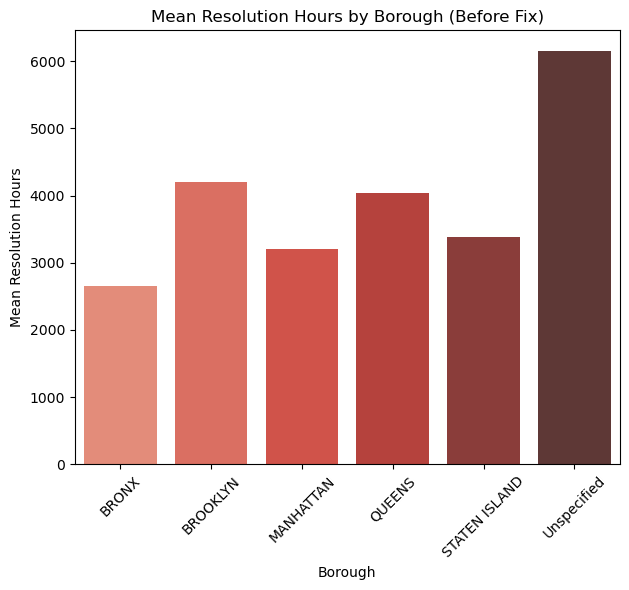

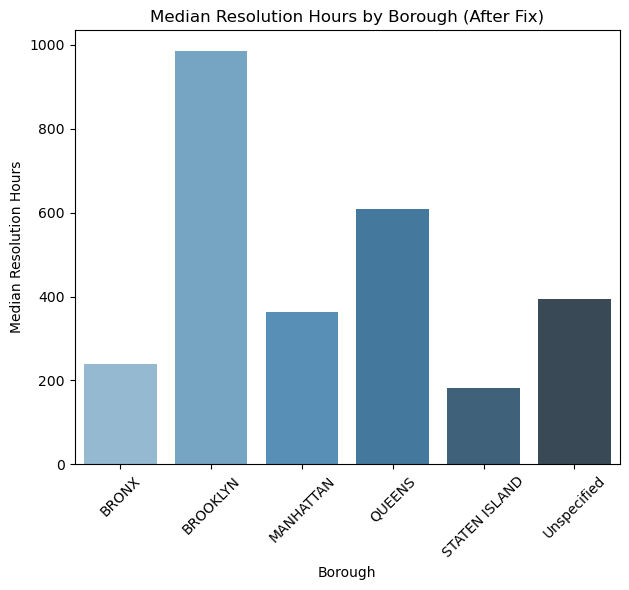

In [917]:
#creates barcharts to show the resolution time used for both optimization models

plt.figure(figsize = (12,6))

# BEFORE: mean resolution hours per borough
plt.subplot(1,2,2)
sns.barplot(x = priority_mean.index, y = priority_mean['Resolution Hours'], 
            hue = priority_mean.index, palette = 'Reds_d')
plt.title("Mean Resolution Hours by Borough (Before Fix)")
plt.xlabel("Borough")
plt.ylabel("Mean Resolution Hours")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))

# AFTER: median resolution hours per borough
plt.subplot(1,2,2)
sns.barplot(x = priority.index, y = priority['Resolution Hours'], 
            hue = priority.index, palette = 'Blues_d')
plt.title("Median Resolution Hours by Borough (After Fix)")
plt.xlabel("Borough")
plt.ylabel("Median Resolution Hours")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()


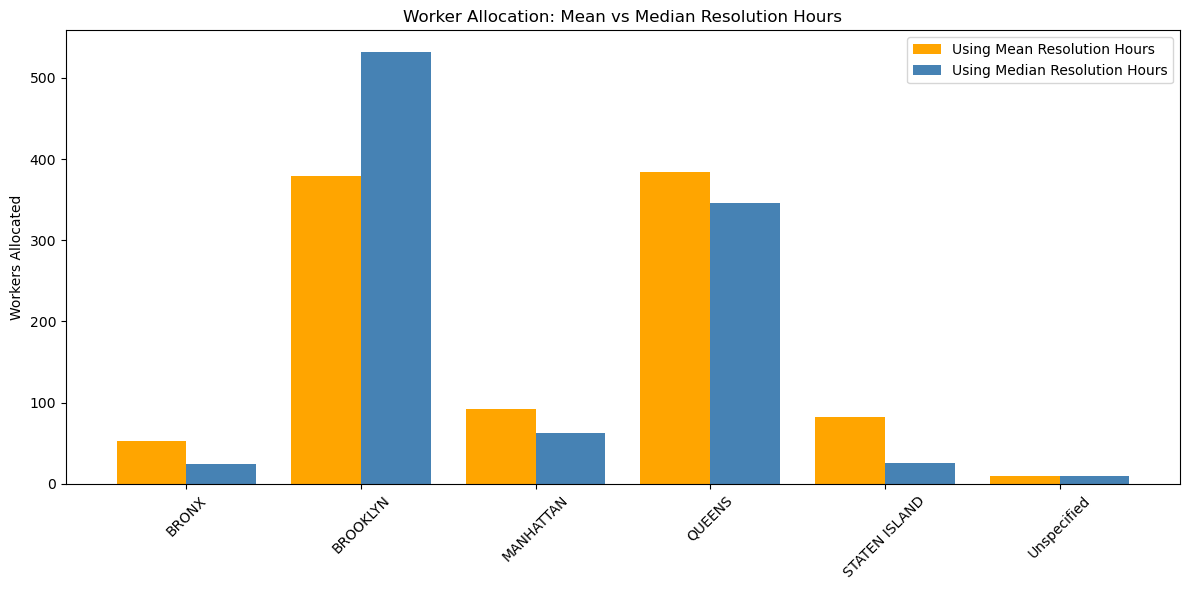

In [919]:
#bar chart to compare the solutions to both optimization models

df_compare = pd.DataFrame({'Borough': priority.index,
                           'Workers_Mean': priority_mean['workers_optimized'],
                           'Workers_Median': priority['workers_optimized']}).reset_index(drop=True)

plt.figure(figsize = (12,6))
bar_width = 0.4
x = range(len(df_compare))

plt.bar(x, df_compare['Workers_Mean'], width = bar_width, label = 'Using Mean Resolution Hours', color = 'orange')
plt.bar([i + bar_width for i in x], df_compare['Workers_Median'], width = bar_width, 
        label = 'Using Median Resolution Hours', color = 'steelblue')

plt.xticks([i + bar_width/2 for i in x], df_compare['Borough'], rotation = 45)
plt.ylabel("Workers Allocated")
plt.title("Worker Allocation: Mean vs Median Resolution Hours")
plt.legend()
plt.tight_layout()
plt.show()


In [939]:
#sensitivity analysis on backlog weight
results = []

#varys the weight of backlog
for w_backlog in [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]:
    priority_backlog = priority.copy()
    priority_backlog['workload'] = priority_backlog['demand'] + w_backlog * priority_backlog['backlog'] #varied
    priority_backlog['workload_hours'] = priority_backlog['workload'] * priority_backlog['Resolution Hours']
    total_workload = priority_backlog['workload_hours'].sum()

    model = pl.LpProblem('WorkerAllocation', pl.LpMinimize)
    model += pl.lpSum([ over[b] + under[b] for b in boroughs])

    for b in boroughs:
        workload_prop = priority_backlog.loc[b, 'workload_hours'] / total_workload
        model += workload_prop - workers[b] / total_workers == over[b] - under[b]
        model += workers[b] >= 10

    model += pl.lpSum([workers[b] for b in boroughs]) == total_workers

    model.solve()

    alloc = {b: workers[b].varValue for b in boroughs}
    alloc['backlog_weight'] = w_backlog
    results.append(alloc)

backlog_weight_results = pd.DataFrame(results)
backlog_weight_results

,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Unspecified,backlog_weight
0,26.0,533.0,69.0,335.0,27.0,10.0,1.0
1,26.0,532.0,65.0,341.0,26.0,10.0,1.5
2,24.0,532.0,62.0,346.0,26.0,10.0,2.0
3,23.0,531.0,57.0,354.0,25.0,10.0,3.0
4,19.0,531.0,49.0,367.0,24.0,10.0,5.0
5,15.0,529.0,38.0,386.0,22.0,10.0,10.0


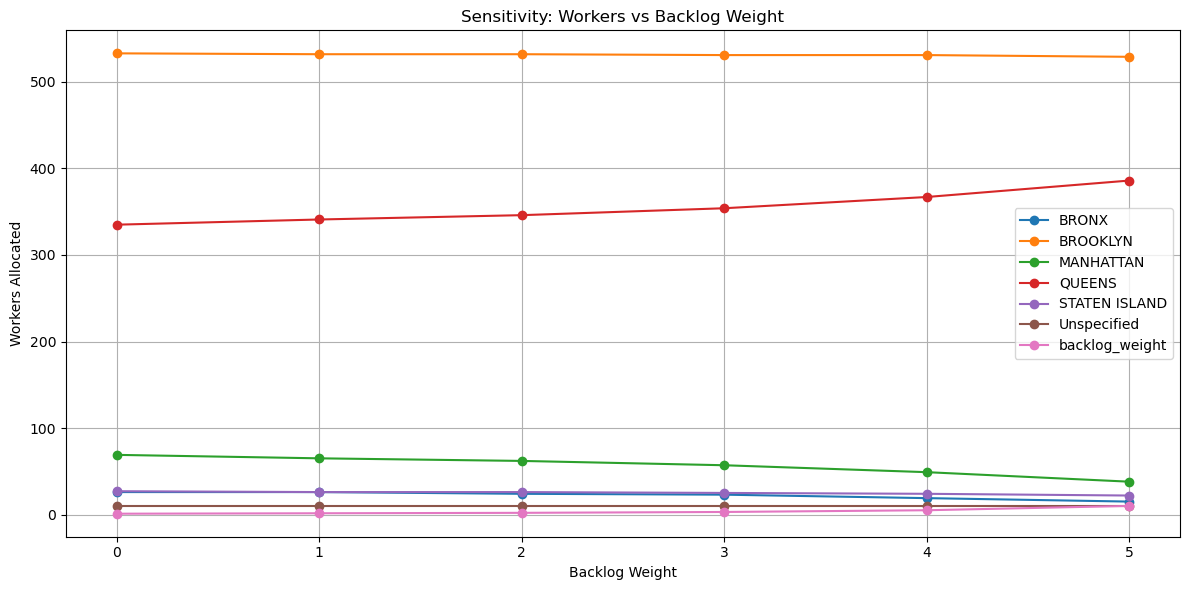

In [923]:
#line chart showing the different solutions when varying the backlog weight
plt.figure(figsize = (12,6))
for borough in backlog_weight_results.columns:
    plt.plot(backlog_weight_results.index, backlog_weight_results[borough], 
             marker = 'o', label = borough)

plt.title("Sensitivity: Workers vs Backlog Weight")
plt.xlabel("Backlog Weight")
plt.ylabel("Workers Allocated")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [945]:
#sensitivity analysis on minimum workers
results = []

for min_workers in [0, 10, 25, 50, 100]:
    priority_min = priority.copy()
    priority_min['workload'] = priority_min['demand'] + 2 * priority_min['backlog']
    priority_min['workload_hours'] = priority_min['workload'] * priority_min['Resolution Hours']
    total_workload = priority_min['workload_hours'].sum()

    model = pl.LpProblem('WorkerAllocation', pl.LpMinimize)
    model += pl.lpSum([over[b] + under[b] for b in boroughs])

    for b in boroughs:
        workload_prop = priority_min.loc[b, 'workload_hours'] / total_workload
        model += workload_prop - workers[b] / total_workers == over[b] - under[b]
        model += workers[b] >= min_workers #varied

    model += pl.lpSum([workers[b] for b in boroughs]) == total_workers

    model.solve()
    
    alloc = {b: workers[b].varValue for b in boroughs}
    alloc['min_workers'] = min_workers
    results.append(alloc)

min_workers_results = pd.DataFrame(results)
min_workers_results

,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Unspecified,min_workers
0,32.0,533.0,63.0,346.0,26.0,0.0,0
1,24.0,532.0,62.0,346.0,26.0,10.0,10
2,25.0,517.0,62.0,346.0,25.0,25.0,25
3,50.0,454.0,50.0,346.0,50.0,50.0,50
4,100.0,254.0,100.0,346.0,100.0,100.0,100


<Figure size 1200x600 with 0 Axes>

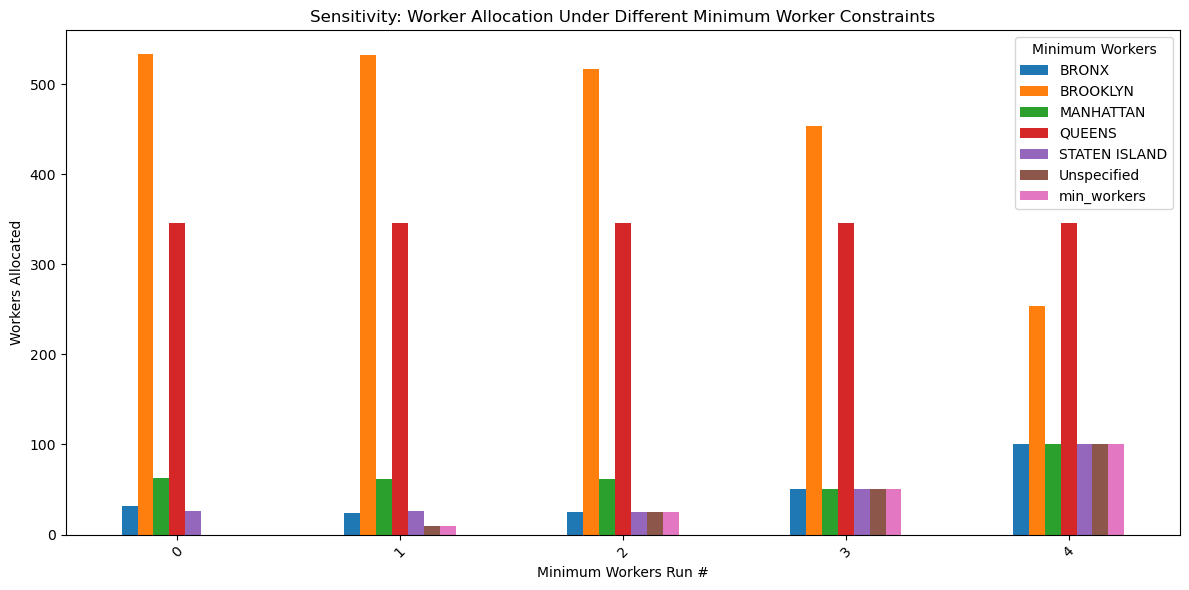

In [947]:
#barchart to show the different solutions with different minimum workers
plt.figure(figsize = (12,6))    
min_workers_results.plot(kind='bar', figsize = (12,6))
plt.title("Sensitivity: Worker Allocation Under Different Minimum Worker Constraints")
plt.xlabel("Minimum Workers Run #")
plt.ylabel("Workers Allocated")
plt.xticks(rotation = 45)
plt.legend(title = "Minimum Workers")
plt.tight_layout()
plt.show()

In [959]:
#sensitiviy analysis for total workers

results = []

for t_workers in [100, 500, 800, 1000, 5000, 10000]:
    priority_totalworkers = priority.copy()
    priority_totalworkers['workload'] = priority_totalworkers['demand'] + 2 * priority_totalworkers['backlog']
    priority_totalworkers['workload_hours'] = priority_totalworkers['workload'] * priority_totalworkers['Resolution Hours']
    total_workload = priority_totalworkers['workload_hours'].sum()

    model = pl.LpProblem('WorkerAllocation', pl.LpMinimize)
    model += pl.lpSum([over[b] + under[b] for b in boroughs])

    for b in boroughs:
        workload_prop = priority_totalworkers.loc[b, 'workload_hours'] / total_workload
        model += workload_prop - workers[b] / t_workers == over[b] - under[b] #varied
        model += workers[b] >= 10

    model += pl.lpSum([workers[b] for b in boroughs]) == t_workers #varied

    model.solve()
    
    alloc = {b: workers[b].varValue for b in boroughs}
    alloc['total_workers'] = t_workers
    results.append(alloc)

total_workers_result = pd.DataFrame(results)
total_workers_result

,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Unspecified,total_workers
0,10.0,26.0,10.0,34.0,10.0,10.0,100
1,16.0,260.0,31.0,173.0,10.0,10.0,500
2,18.0,425.0,49.0,277.0,21.0,10.0,800
3,24.0,532.0,62.0,346.0,26.0,10.0,1000
4,154.0,2662.0,312.0,1731.0,131.0,10.0,5000
5,317.0,5324.0,624.0,3463.0,262.0,10.0,10000


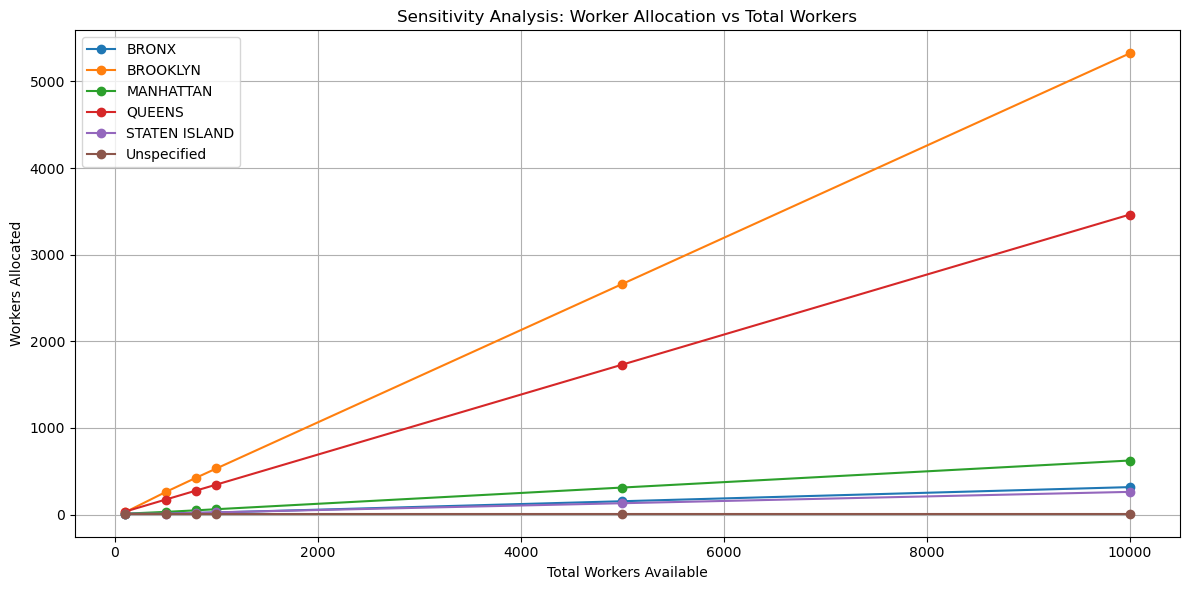

In [961]:
#line chart showing the worker allocation with different total worker numbers
plt.figure(figsize=(12,6))

# List of borough columns
borough_cols = ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND', 'Unspecified']

for borough in borough_cols:
    plt.plot(total_workers_result['total_workers'], 
             total_workers_result[borough], 
             marker='o', 
             label=borough)

plt.title("Sensitivity Analysis: Worker Allocation vs Total Workers")
plt.xlabel("Total Workers Available")
plt.ylabel("Workers Allocated")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [991]:
#sensitivity analysis for weight of demand

results = []
total_workers = 1000

for w_demand in [1.0, 1.5, 2.0, 3.0, 5.0, 10.0]:
    priority_workload = priority.copy()
    priority_workload['workload'] = w_demand * priority_workload['demand'] + 2 * priority_workload['backlog'] #varied
    priority_workload['workload_hours'] = priority_workload['workload'] * priority_workload['Resolution Hours']
    total_workload = priority_workload['workload_hours'].sum()

    model = pl.LpProblem('WorkerAllocation', pl.LpMinimize)
    model += pl.lpSum([over[b] + under[b] for b in boroughs])

    for b in boroughs:
        workload_prop = priority_workload.loc[b, 'workload_hours'] / total_workload
        model += workload_prop - workers[b] / total_workers == over[b] - under[b]
        model += workers[b] >= 10

    model += pl.lpSum([workers[b] for b in boroughs]) == total_workers

    model.solve()
    
    alloc = {b: workers[b].varValue for b in boroughs}
    alloc['w_demand'] = w_demand
    results.append(alloc)

demand_results = pd.DataFrame(results)
demand_results

,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND,Unspecified,w_demand
0,24.0,532.0,62.0,346.0,26.0,10.0,1.0
1,27.0,532.0,66.0,339.0,26.0,10.0,1.5
2,26.0,533.0,69.0,335.0,27.0,10.0,2.0
3,28.0,533.0,71.0,331.0,27.0,10.0,3.0
4,29.0,533.0,73.0,327.0,28.0,10.0,5.0
5,30.0,533.0,75.0,324.0,28.0,10.0,10.0


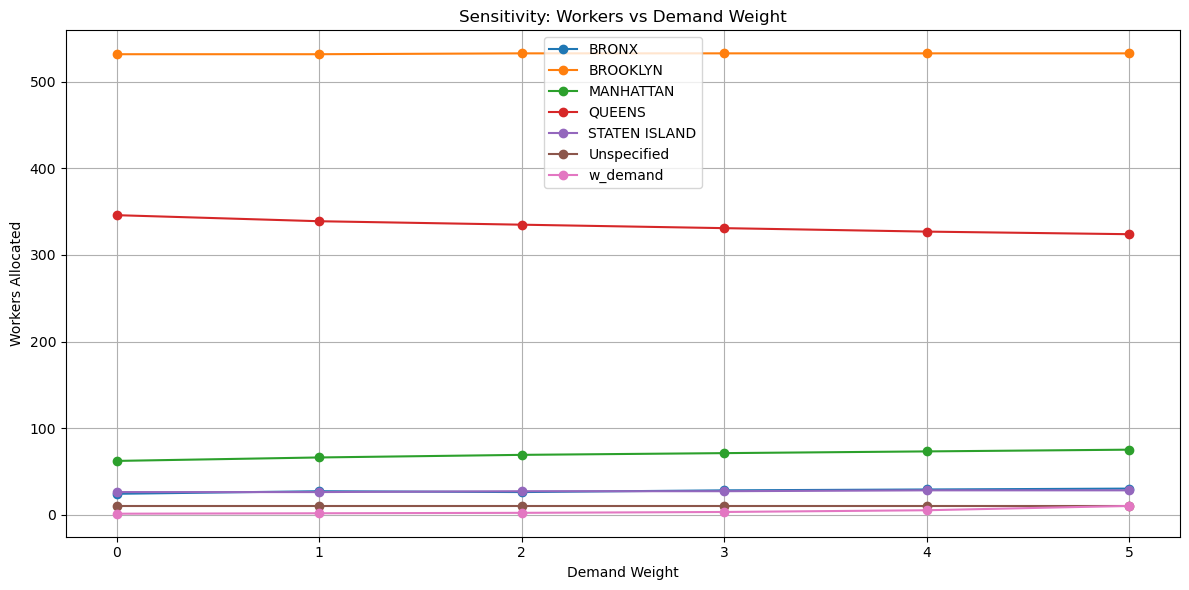

In [993]:
#line chart to show different solutions for demand weight

plt.figure(figsize = (12,6))
for borough in demand_results.columns:
    plt.plot(demand_results.index, demand_results[borough], 
             marker = 'o', label = borough)

plt.title("Sensitivity: Workers vs Demand Weight")
plt.xlabel("Demand Weight")
plt.ylabel("Workers Allocated")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [981]:
#calculates the share of work and workers each borough has
total_workers = 1000
priority['workload_share'] = priority['workload_hours'] / priority['workload_hours'].sum()
priority['worker_share'] = priority['workers_optimized'] / total_workers

#shows the difference of workload and worker share
priority['share_gap'] = priority['worker_share'] - priority['workload_share']
priority

,Resolution Hours,demand,backlog,workload,capacity_per_worker,workload_hours,workers_optimized,workload_share,worker_share,share_gap
Borough,,,,,,,,,,
BRONX,238.431944,47912,2692,53296,0.004194,1.270747e+07,24.0,0.032386,0.024,-0.008386
BROOKLYN,985.673333,163679,24146,211971,0.001015,2.089342e+08,532.0,0.532486,0.532,-0.000486
MANHATTAN,362.457222,64711,1434,67579,0.002759,2.449450e+07,62.0,0.062426,0.062,-0.000426
QUEENS,608.776806,159590,31834,223258,0.001643,1.359143e+08,346.0,0.346389,0.346,-0.000389
STATEN ISLAND,180.733611,48191,4436,57063,0.005533,1.031320e+07,26.0,0.026284,0.026,-0.000284
Unspecified,394.050278,22,3,28,0.002538,1.103341e+04,10.0,0.000028,0.010,0.009972


In [983]:
#shows correlation of workload hours and amount of workers given
priority[['workload_hours', 'workers_optimized']].corr()

,workload_hours,workers_optimized
workload_hours,1.000000,0.999651
workers_optimized,0.999651,1.000000


In [892]:
#shows correlation of demand and amount of workers given
priority[['demand', 'workers_optimized']].corr()

,demand,workers_optimized
demand,1.000000,0.933597
workers_optimized,0.933597,1.000000


In [894]:
#shows correlation of backlog and amount of workers given
priority[['backlog', 'workers_optimized']].corr()

,backlog,workers_optimized
backlog,1.000000,0.892157
workers_optimized,0.892157,1.000000


In [896]:
#shows correlation of resolution time and amount of workers given
priority[['Resolution Hours', 'workers_optimized']].corr()

,Resolution Hours,workers_optimized
Resolution Hours,1.000000,0.952598
workers_optimized,0.952598,1.000000


In [898]:
#shows a summary of work by borough
workload_summary = priority[['demand', 'backlog', 'Resolution Hours', 'workload_hours']].copy()
workload_summary = workload_summary.rename(columns = {
    'Resolution Hours': 'median_resolution_hours'})

print(workload_summary)

               demand  backlog  median_resolution_hours  workload_hours
Borough                                                                
BRONX           47912     2692               238.431944    5.840247e+07
BROOKLYN       163679    24146               985.673333    8.542703e+08
MANHATTAN       64711     1434               362.457222    1.183144e+08
QUEENS         159590    31834               608.776806    5.245331e+08
STATEN ISLAND   48191     4436               180.733611    4.515214e+07
Unspecified        22        3               394.050278    4.570983e+04


<Figure size 1000x600 with 0 Axes>

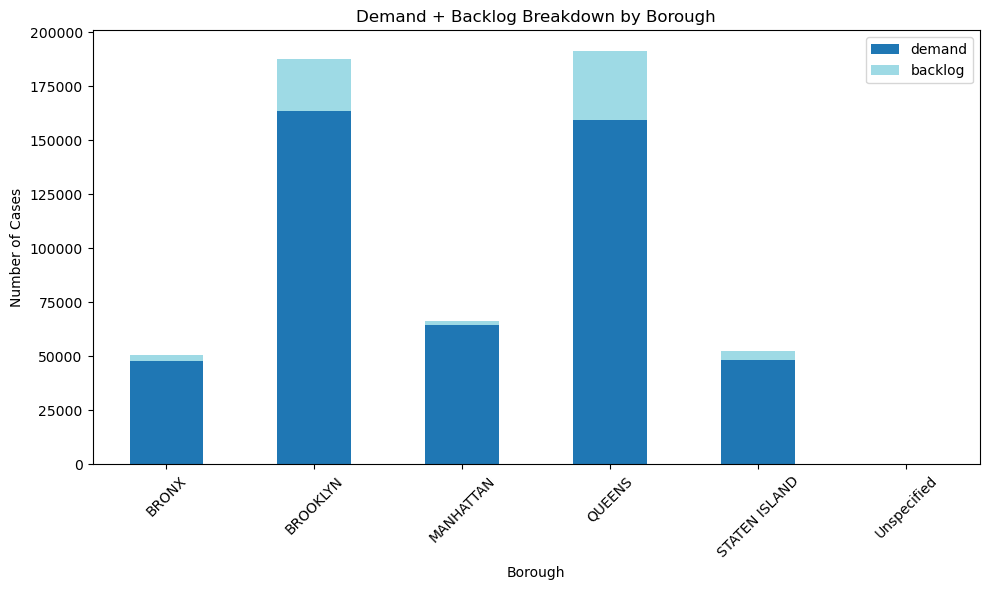

In [900]:
#bar chart for the demand and backlog of each borough
plt.figure(figsize = (10,6))

priority[['demand', 'backlog']].plot(kind = 'bar', stacked = True,
                                     figsize = (10,6), colormap = 'tab20')

plt.title("Demand + Backlog Breakdown by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Cases")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

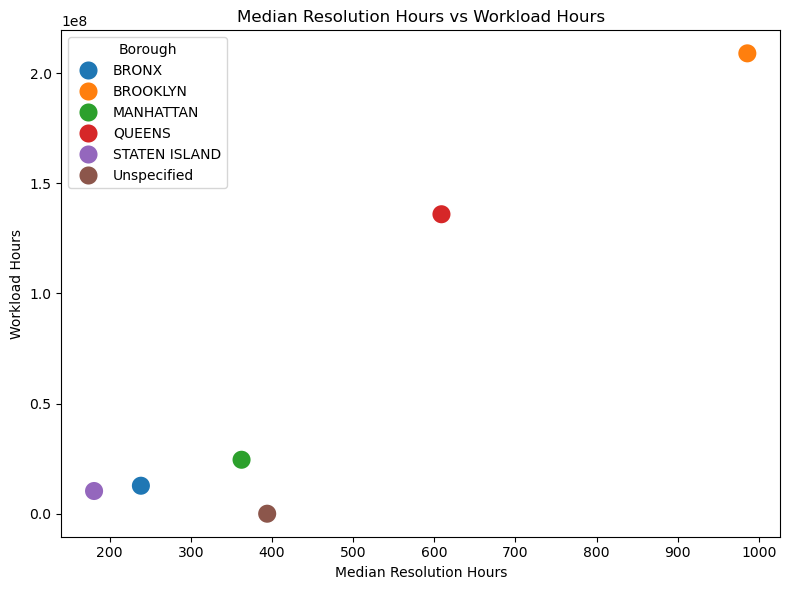

In [985]:
#scatterplot for the median resolution time vs the amount of time needed for the work
plt.figure(figsize = (8,6))
sns.scatterplot(data = priority, x = 'Resolution Hours', y = 'workload_hours',
                hue = priority.index, s = 200)

plt.title("Median Resolution Hours vs Workload Hours")
plt.xlabel("Median Resolution Hours")
plt.ylabel("Workload Hours")
plt.tight_layout()
plt.show()

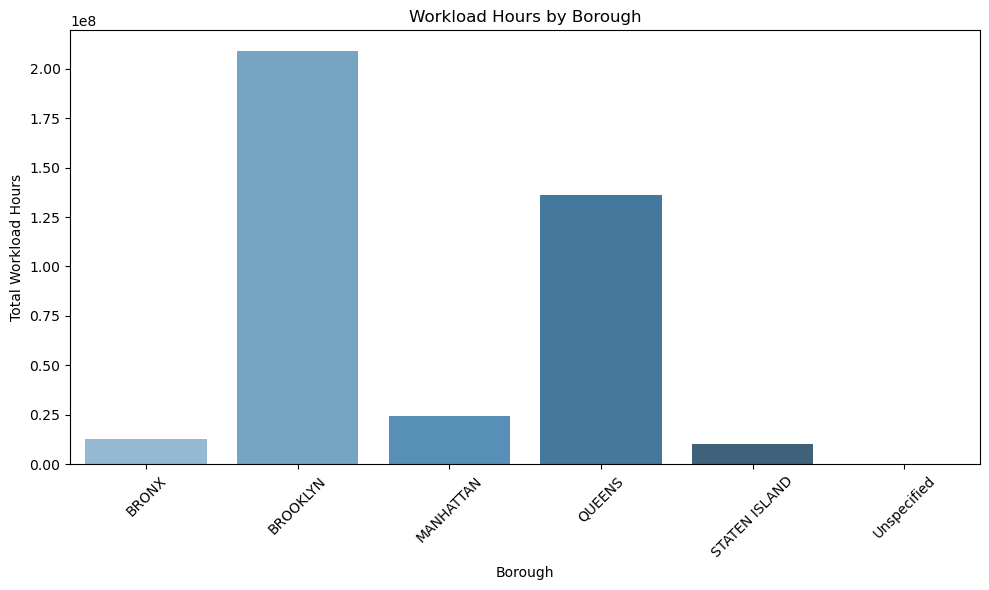

In [987]:
#barplot for hours needed to complete the requests for each borough
plt.figure(figsize = (10,6))
sns.barplot(data=priority.reset_index(), x = 'Borough', y = 'workload_hours',
            hue = 'Borough', palette = 'Blues_d')

plt.title("Workload Hours by Borough")
plt.xlabel("Borough")
plt.ylabel("Total Workload Hours")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

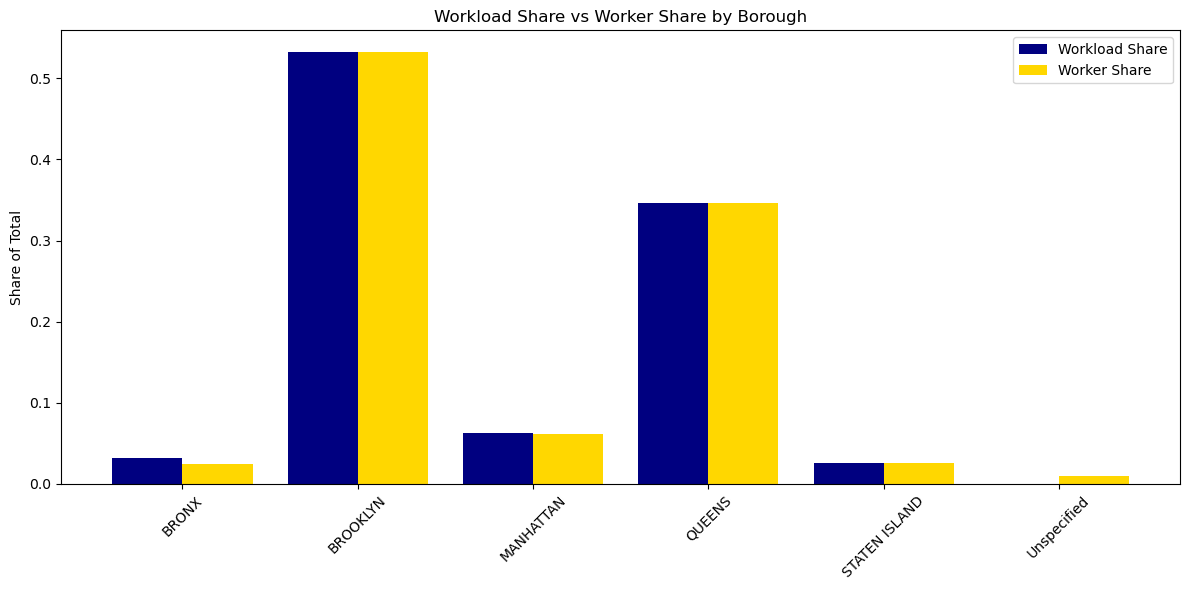

In [989]:
#barchart to compare workload share and worker share each borough has
df = priority.copy()
df['workload_share'] = df['workload_hours'] / df['workload_hours'].sum()
df['worker_share'] = df['workers_optimized'] / df['workers_optimized'].sum()
df = df.reset_index()

plt.figure(figsize=(12,6))
bar_width = 0.4
x = range(len(df))

plt.bar(x, df['workload_share'], width = bar_width, label = 'Workload Share', color = 'navy')
plt.bar([i + bar_width for i in x], df['worker_share'], width = bar_width, 
        label = 'Worker Share', color='gold')

plt.xticks([i + bar_width/2 for i in x], df['Borough'], rotation = 45)
plt.ylabel("Share of Total")
plt.title("Workload Share vs Worker Share by Borough")
plt.legend()
plt.tight_layout()
plt.show()

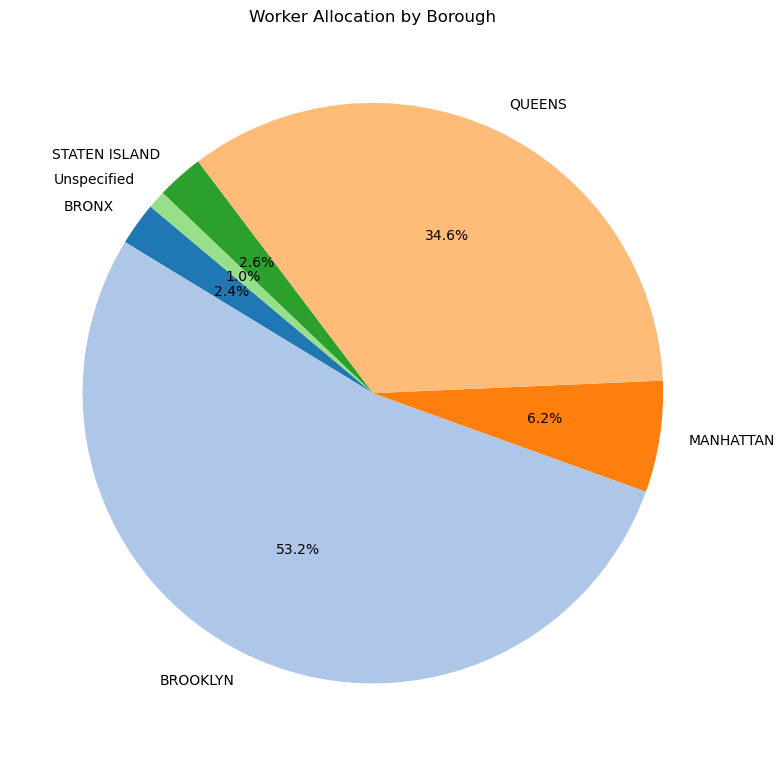

In [973]:
#pie chart for the percent of workers each borough has
plt.figure(figsize=(8,8))
plt.pie(priority['workers_optimized'], labels = priority.index,
    autopct = '%1.1f%%', startangle = 140, colors = sns.color_palette('tab20'))
plt.title("Worker Allocation by Borough")
plt.tight_layout()
plt.show()